# Pima Indian Diabetes Analysis
The aim of this project to analyze the medical factors of a patient such as Glucose Level, Blood Pressure, Skin Thickness, Insulin Level and many others to predict whether the patient has diabetes or not.

## About the Dataset
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

The datasets consists of several medical predictor variables and one target variable, Outcome. Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

## Problem Statement

Diabetes is one of the fastest-growing chronic diseases globally and early diagnosis is critical to prevent severe complications such as heart disease, kidney failure, and vision loss. The Pima Indian population has a particularly high prevalence of diabetes. The challenge is to analyze key medical diagnostic factors such as Glucose Level, Blood Pressure, Skin Thickness, Insulin Level, BMI, Diabetes Pedigree Function, Age, and Pregnancies to understand patterns and identify which factors are most strongly associated with diabetes.

This analysis addresses the problem of late and uncertain diabetes detection by performing a detailed Exploratory Data Analysis (EDA) on the Pima Indian Diabetes dataset to uncover insights that can support early prediction and better medical decision-making.

## Objective

The main objectives of this Diabetes Analysis are:

1. To load, clean, and explore the Pima Indian Diabetes dataset (768 records, 8 predictor variables + 1 target variable `Outcome`).
2. To check data quality in terms of missing values, duplicates, invalid zeros, and descriptive statistics.
3. To visualize the distribution of diabetic vs non-diabetic patients.
4. To analyze the relationship between each medical feature (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age) and diabetes outcome.
5. To identify the strongest indicators/predictors of diabetes that can be used for future predictive modelling.

## Research Questions

This analysis seeks to answer the following research questions:

1. What is the proportion of diabetic vs non-diabetic patients in the dataset?
2. Which medical features (Glucose, BMI, Insulin, Age, etc.) have the strongest association with diabetes?
3. How do Glucose level, BMI, Skin Thickness, Insulin level, and Diabetes Pedigree Function differ between diabetic and non-diabetic patients?
4. Do Pregnancies and Age increase the risk of diabetes?
5. Is Blood Pressure a good predictor of diabetes, or is its effect minimal compared to other features?

# Step 1: Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Step 2 - Loading the Data

In [2]:
df=pd.read_csv('diabetes.csv')

# Step 3 - Exploratory Data Analysis (EDA)

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

# Step 4 - Starting Data Cleaning

In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Step 5 - Check for Duplicates

In [6]:
df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [7]:
(df == 0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Step 6 - Checking for Invalid Categories

In [9]:
df['Pregnancies'].value_counts(normalize=True)

Pregnancies
1     0.175781
0     0.144531
2     0.134115
3     0.097656
4     0.088542
5     0.074219
6     0.065104
7     0.058594
8     0.049479
9     0.036458
10    0.031250
11    0.014323
13    0.013021
12    0.011719
14    0.002604
15    0.001302
17    0.001302
Name: proportion, dtype: float64

# Step 7 - Make outcomes human-readable

In [10]:
df['Outcome'] = df['Outcome'].replace({
 0: 'Negative',
 1: 'Positive'
})

In [11]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,Positive
1,1,85,66.0,29,102.5,26.6,0.351,31,Negative
2,8,183,64.0,32,169.5,23.3,0.672,32,Positive
3,1,89,66.0,23,94.0,28.1,0.167,21,Negative
4,0,137,40.0,35,168.0,43.1,2.288,33,Positive


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 54.1+ KB


# Step 8 - Exploratory Data Analysis

In the exploratory data analysis, I will be looking at the distribution of the data, the correlation between the features, and the relationship between the features and the target variable. I will start by looking at the distribution of the data, followed by relationship between the target variable and independent variables.

Text(0.5, 1.0, 'Diabetes Outcome')

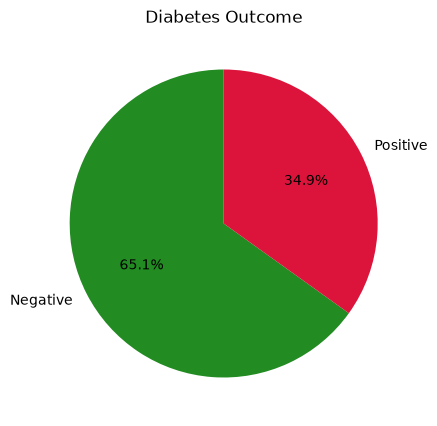

In [13]:
plt.figure(figsize=(5,5))
plt.pie(df['Outcome'].value_counts(), labels=['Negative', 'Positive'], autopct='%1.1f%%', shadow=False, startangle=90,colors=['#228B22','#DC143C'])
plt.title('Diabetes Outcome')

# Age Distribution and Diabetes

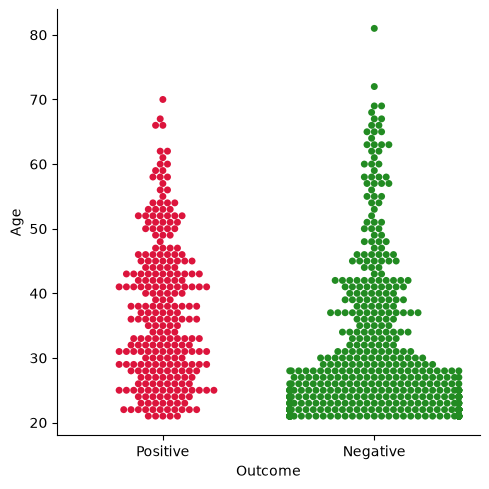

In [14]:
sns.catplot(x="Outcome", y="Age", kind="swarm", data=df, palette=['#DC143C','#228B22'])

From the graph, it is quite clear that majority of the patients are adult within the age group of 20-30 years. Patients in the age range 40-55 years are more prone to diabetes, as compared to other age groups. Since the number adults in the age group 20-30 years is more, the number of patients with diabetes is also more as compared of other age groups.

# Pregnancies and Diabetes

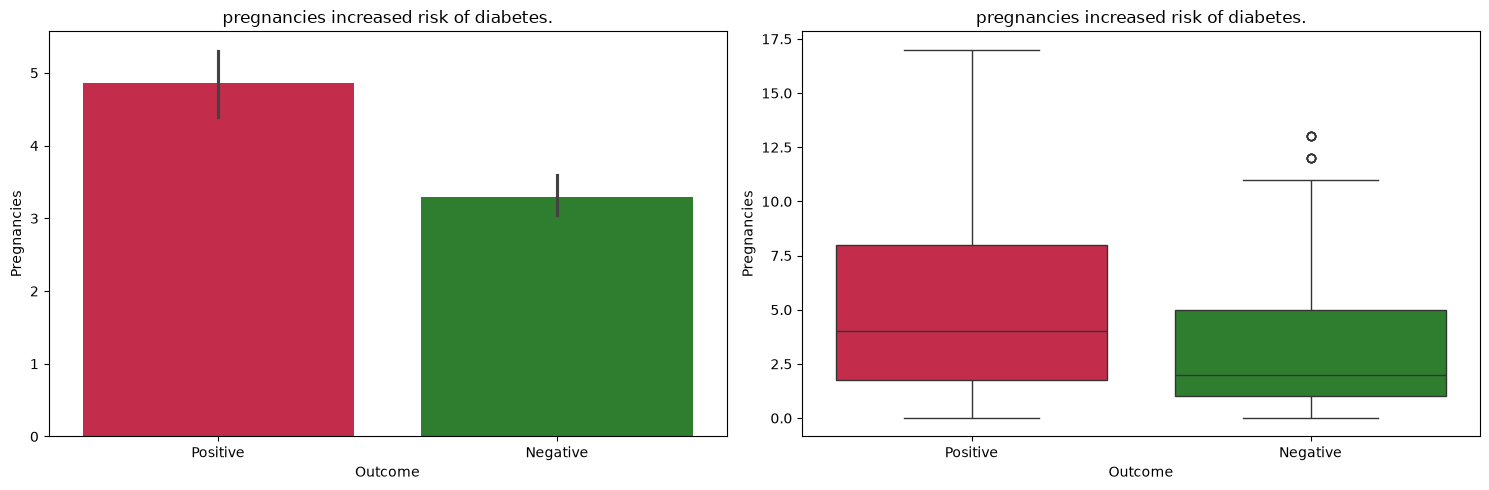

In [15]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title('pregnancies increased risk of diabetes.')
sns.barplot(x='Outcome', y='Pregnancies', data=df,palette=['#DC143C','#228B22'])

plt.subplot(1, 2, 2)
plt.title('pregnancies increased risk of diabetes.')
sns.boxplot(x='Outcome', y='Pregnancies', data=df,palette=['#DC143C','#228B22'])

plt.tight_layout()

Both boxplot and barplot shows strange relation between the number of preganacies and diabetes. According to the graphs the increased number of pregnancies highlights increased risk of diabetes.

# Glucose vs Diabetes

Text(0.5, 1.0, 'Glucose vs Diabetes')

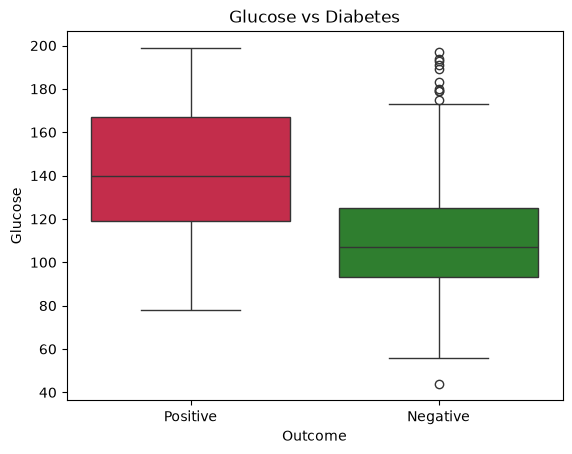

In [16]:
sns.boxplot(x='Outcome', y='Glucose', data=df,palette=['#DC143C','#228B22']).set_title('Glucose vs Diabetes')

Glucose level plays a major role in determine whether the patient is diabetic or not. The patients with median gluocse level less than 120 are more likely to be non-diabetic. The patients with median gluocse level greather than 140 are more likely to be diabetic. Therefore, high gluocose levels is a good indicator of diabetes.

# Blood Pressure VS Diabetes

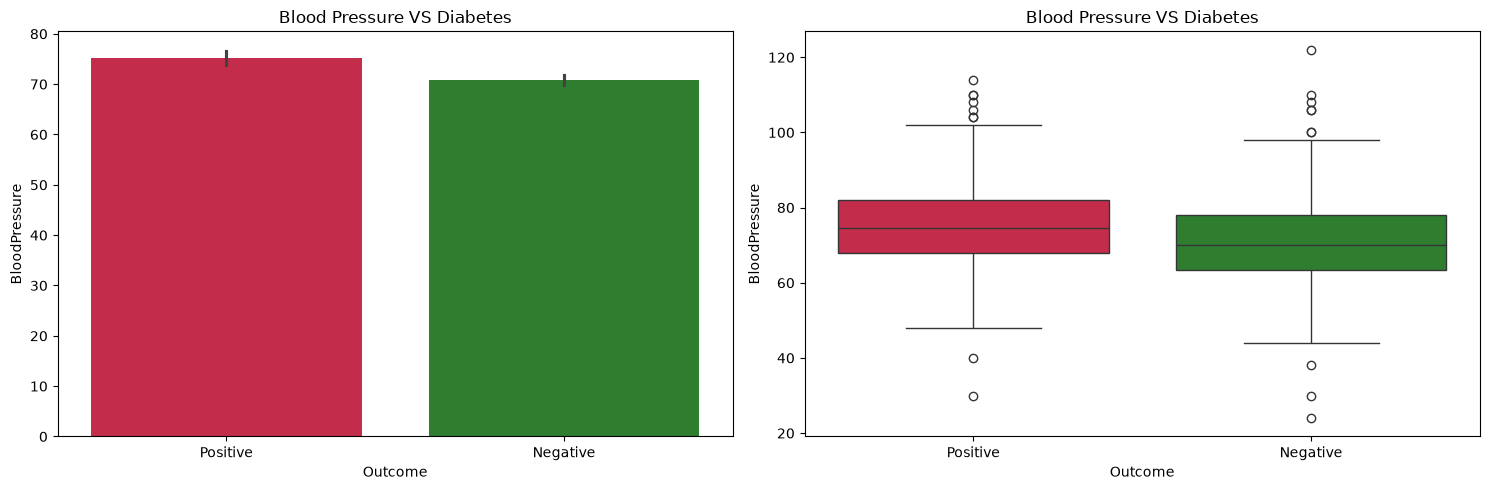

In [17]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title('Blood Pressure VS Diabetes')
sns.barplot(x='Outcome', y='BloodPressure', data=df,palette=['#DC143C','#228B22'])

plt.subplot(1, 2, 2)
plt.title('Blood Pressure VS Diabetes')
sns.boxplot(x='Outcome', y='BloodPressure', data=df,palette=['#DC143C','#228B22'])

plt.tight_layout()

Both the boxplot and Barplot provides clear understanding of the realtion between the blood pressure and diabetes. The boxplot shows that the median of the blood pressure for the diabetic patients is slightly higher than the non-diabetic patients. The voilinplot shows that the distribution of the blood pressure for the diabetic patients is slightly higher than the non-diabetic patients. But there has been not enough evidence to conclude that the blood pressure is a good predictor of diabetes.

# Skin Thickness VS Diabetes

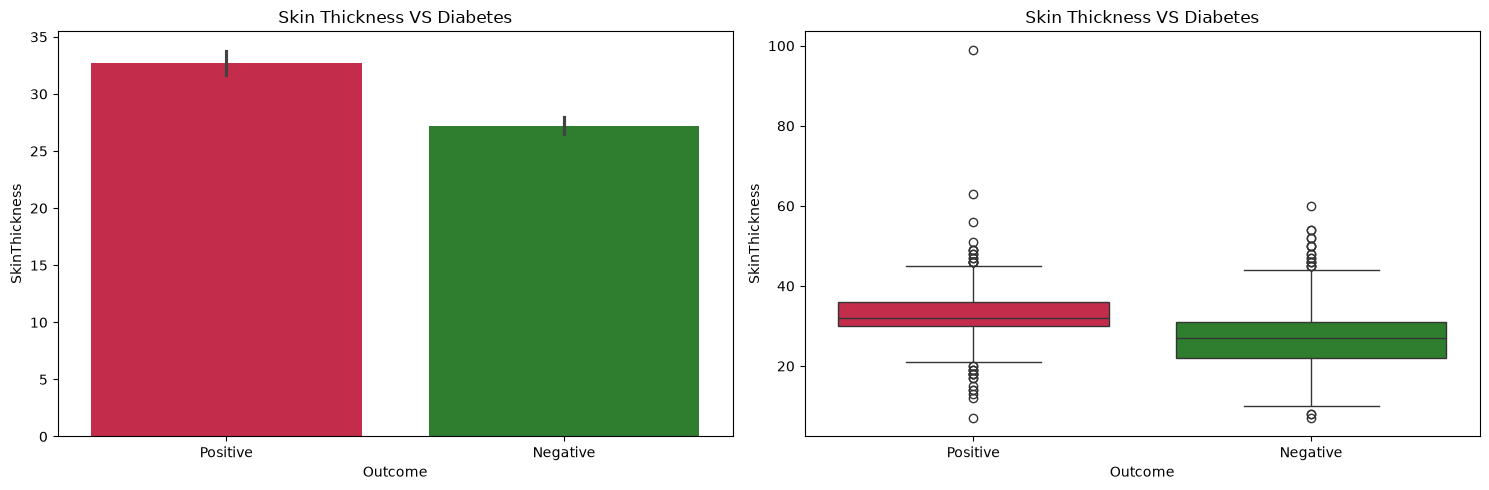

In [18]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title('Skin Thickness VS Diabetes')
sns.barplot(x='Outcome', y='SkinThickness', data=df,palette=['#DC143C','#228B22'])

plt.subplot(1, 2, 2)
plt.title('Skin Thickness VS Diabetes')
sns.boxplot(x='Outcome', y='SkinThickness', data=df,palette=['#DC143C','#228B22'])

plt.tight_layout()

Here both the boxplot and violinplot reveals the effect of diabetes on skin thickness. As obserevd in the boxplot, the median of skin thickness is higher for the diabetic patients than the non-diabetic patients, where non diabetic patients have median skin thickness near 20 in comparison to skin thickness nearly 30 in diabetic patients. The voilinpplot shows the distribution of patients' skin thickness amoung the patients, where the non diabetic ones have greater distribution near 20 and diabetic much less distribution near 20 and increased distribution near 30. Therefore, skin thickness can be a indicator of diabetes.

# Insulin VS Diabetes

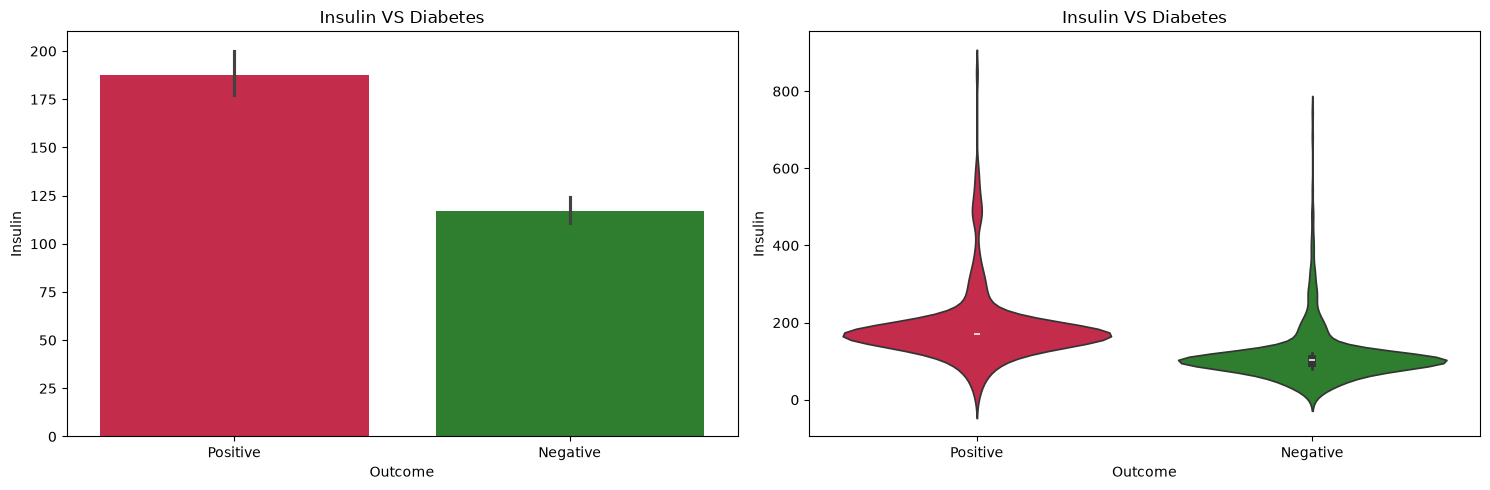

In [19]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title('Insulin VS Diabetes')
sns.barplot(x='Outcome', y='Insulin', data=df,palette=['#DC143C','#228B22'])

plt.subplot(1, 2, 2)
plt.title('Insulin VS Diabetes')
sns.violinplot(x='Outcome', y='Insulin', data=df,palette=['#DC143C','#228B22'])

plt.tight_layout()

Insulin is a major body hormone that regulates glucose metabolism. Insulin is required for the body to efficiently use sugars, fats and proteins. Any change in insulin amount in the body would result in change glucose levels as well. Here the boxplot and violinplot shows the distribution of insulin level in patients. In non diabetic patients the insulin level is near to 100, whereas in diabetic patients the insulin level is near to 200. In the voilinplot we can see that the distribution of insulin level in non diabetic patients is more spread out near 100, whereas in diabetic patients the distribution is contracted and shows a little bit spread in higher insulin levels. This shows that the insulin level is a good indicator of diabetes.

# BMI VS Diabetes

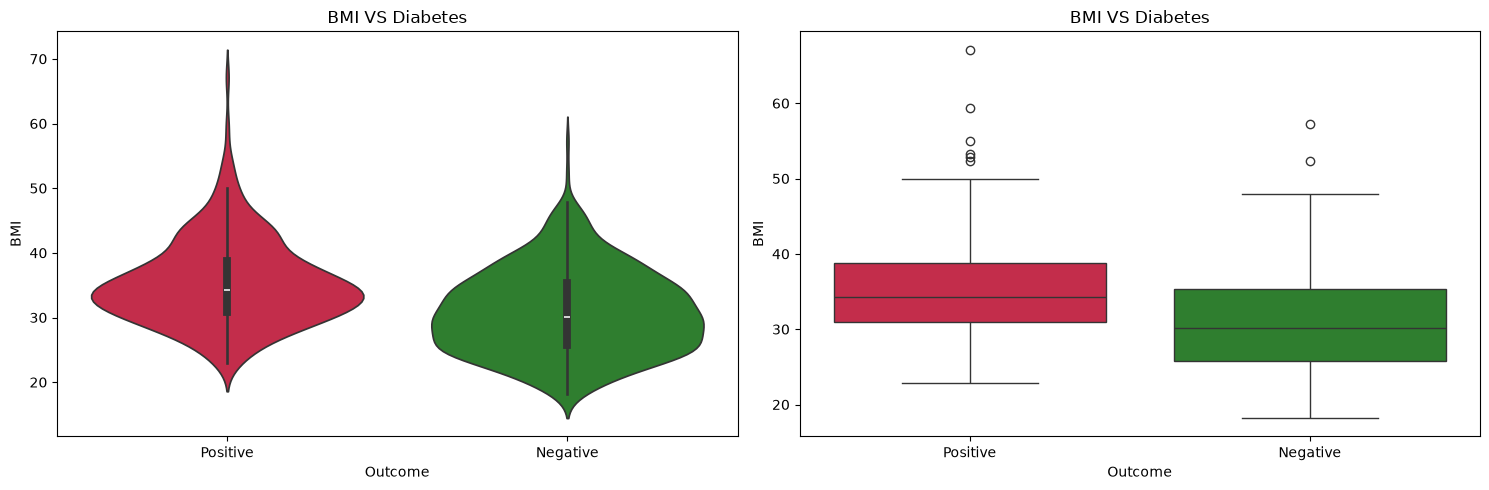

In [20]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title('BMI VS Diabetes')
sns.violinplot(x='Outcome', y='BMI', data=df,palette=['#DC143C','#228B22'])

plt.subplot(1, 2, 2)
plt.title('BMI VS Diabetes')
sns.boxplot(x='Outcome', y='BMI', data=df,palette=['#DC143C','#228B22'])

plt.tight_layout()

Both graphs highlights the role of BMI in diabetes prediction. Non diabetic patients have a normal BMI within the range of 25-35 whereas the diabetic patients have a BMI greater than 35. The violinplot reveals the BMI distribution, where the non dibetic patients have a increased spread from 25 to 35 with narrows after 35. However in diabetic patients there is increased spread at 35 and increased spread 45-50 as compared to non diabetic patients.Therefore BMI is a good predictor of diabetes and obese people are more likely to be diabetic.

#  Diabetes Pedigree Function VS Diabetes

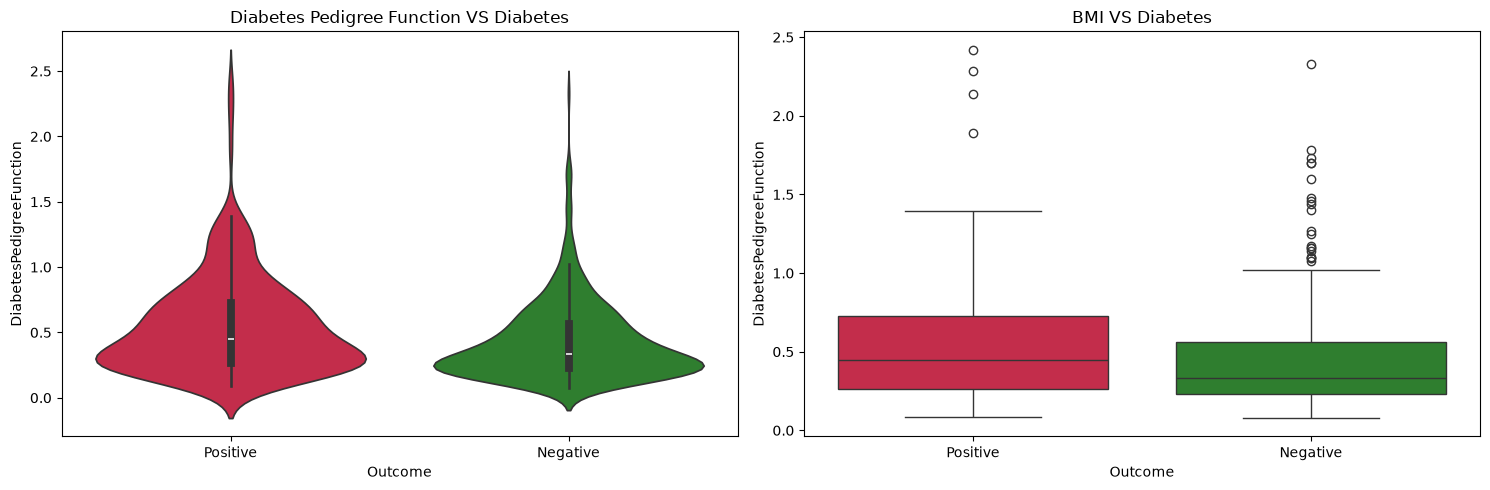

In [24]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title('Diabetes Pedigree Function VS Diabetes')
sns.violinplot(x='Outcome', y='DiabetesPedigreeFunction', data=df,palette=['#DC143C','#228B22'])

plt.subplot(1, 2, 2)
plt.title('BMI VS Diabetes')
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df,palette=['#DC143C','#228B22'])

plt.tight_layout()

Diabetes Pedigree Function (DPF) calculates diabetes likelihood depending on the subject's age and his/her diabetic family history. From the boxplot, the patients with lower DPF, are much less likely to have diabetes. The patients with higher DPF, are much more likely to have diabetes. In the violinplot, majority of the non diabetic patients have a DPF of 0.25-0.35, whereas the diabetic patients have a increased DPF, which is shown by the their distribution in the violinplot where there is a increased spread in the DPF from 0.5 -1.5. Therefore the DPF is a good indicator of diabetes.

## Conclusion

From the Exploratory Data Analysis of the Pima Indian Diabetes dataset (768 female patients, 21+ years), the following key conclusions are drawn:

1. **Class Distribution:** About 65.1% patients are Non-Diabetic (Negative) and 34.9% are Diabetic (Positive), showing a moderately imbalanced dataset.
2. **Data Quality:** No missing values and no duplicate records were found. Descriptive statistics helped identify biologically invalid zeros and outliers that need handling before modelling.
3. **Strongest Predictors:**
   - **Glucose** is the strongest indicator - diabetic patients typically have median glucose > 140, while non-diabetic have < 120.
   - **BMI:** Diabetic patients have higher BMI (>35, obese range) vs 25-35 for non-diabetic, confirming obesity as a major risk factor.
   - **Insulin:** Diabetic patients show insulin levels near 200 vs ~100 for non-diabetic.
   - **Skin Thickness:** Median ~30 for diabetic vs ~20 for non-diabetic.
   - **Diabetes Pedigree Function:** Higher DPF (0.5-1.5) indicates higher diabetes likelihood due to family history and age effect.
4. **Moderate Factors:** Higher number of **Pregnancies** and higher **Age (40-55 years)** are associated with increased diabetes risk.
5. **Weak Predictor:** **Blood Pressure** shows only a slightly higher median for diabetic patients, with not enough evidence to be a strong standalone predictor.

Overall, Glucose, BMI, Insulin, Skin Thickness, and Diabetes Pedigree Function are good indicators of diabetes, while Age and Pregnancies provide supporting risk information. These insights form a strong basis for the next step: building machine learning classification models to predict diabetes early and accurately.